# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import netCDF4 as nc4;        import pandas as pd
import requests;              import json;
import matplotlib as mpl;     import matplotlib.pyplot as plt
import matplotlib.tri as tri; import pathlib as pl
import cartopy.crs as ccrs;   import cartopy.io.img_tiles as cart_img
import cartopy as cart;       import cartopy.io.img_tiles as cimgt
import numpy as np;           import wse
import skill_metrics as sm;   import geopandas as gpd
import calendar;              import plotly.graph_objects as go
import seaborn as sns;        import xarray as xr
import math
from scipy.stats import linregress
import pymannkendall as mk
from matplotlib.offsetbox import AnchoredText
from shapely import Polygon,Point,MultiPoint,LineString,MultiLineString;import shapely.vectorized
from scipy.stats import linregress
from sklearn.metrics import root_mean_squared_error
from plotly.subplots import make_subplots
import plotly.colors as pc

salloc --ntasks=40 --nodes=1 --partition=normal --mem-per-cpu=8GB --time=06:00:00

source $HOME/miniforge3/bin/activate

### Defined Functions

#### Data for this exercise can be found here
https://doi.org/10.17603/ds2-h0fw-2p96

Download the swan_HS.63.nc from one of the 4 folders

---

### Initialize path and read netcdf file

In [2]:
root = pl.Path('/scratch/tmiesse/project/data4trends')
years       = ['1980','1981','1982','1983','1984','1985','1987','1988','1989',
               '1990','1991','1992','1993','1994','1995','1996',
               '1997','1998','1999','2000','2001','2002','2003',
               '2004','2005','2006','2007','2008','2009','2010',
               '2011','2012','2013',
               '2019','2020','2021','2022','2023','2024']#'2014','2015','2016','2017','2018','2019',

#### Read metadata within netcdf file

_____________________________________

In [3]:
percentiles = [0.5, 0.9, 0.95, 0.99, 0.995, 0.999]
# ────────────────────────────────────────────────────────────────────────────────

def decode_comms(raw):
    return [
        v.tobytes().decode('ascii').rstrip('\x00').strip().lower()
        for v in raw
    ]

def pct_label(p):
    s = f"{p*100:.1f}"
    if s.endswith('.0'):
        s = s[:-2]
    return f"{s}th"

# 1) discover unique communities
with nc4.Dataset(str(root / f"{years[0]}.nc")) as ds0:
    comms0 = decode_comms(ds0.variables['community'][:])
unique_comms = []
for c in comms0:
    if c not in unique_comms:
        unique_comms.append(c)

# 2) cache per‑year times
time_year = {}
for yr in years:
    with nc4.Dataset(str(root / f"{yr}.nc")) as ds:
        tvar = ds.variables['time']
        time_year[yr] = nc4.num2date(
            tvar[:], tvar.units,
            getattr(tvar, 'calendar', 'standard')
        )

# 3) collect raw series, swapping in Shaktoolik’s iceaf for Unalakleet
raw = {c: {'time': [], 'hs': [], 'iceaf': []} for c in unique_comms}

for yr in years:
    with nc4.Dataset(str(root / f"{yr}.nc")) as ds:
        comms   = decode_comms(ds.variables['community'][:])
        idx_map = {c: i for i, c in enumerate(comms)}
        shak_i  = idx_map['shaktoolik']

        for comm in unique_comms:
            hs_idx  = idx_map[comm]
            ice_idx = shak_i if comm == 'unalakleet' else idx_map[comm]

            hs_ma  = ds.variables['swan_HS'][:, hs_idx]
            ice_ma = ds.variables['iceaf'][:, ice_idx]

            raw[comm]['time'].extend(time_year[yr].tolist())
            raw[comm]['hs'].   extend(hs_ma.filled(np.nan).tolist())
            raw[comm]['iceaf'].extend(ice_ma.filled(np.nan).tolist())

# 4) compute monthly & annual percentiles + extrema for HS & iceaf
monthly_data = {}

for comm, data in raw.items():
    times      = np.array(data['time'])
    hs_arr     = np.array(data['hs'])
    ice_arr    = np.array(data['iceaf'])
    years_arr  = np.array([t.year  for t in times])
    months_arr = np.array([t.month for t in times])

    monthly_data[comm] = {}
    for yr in years:
        yi     = int(yr)
        mask_y = (years_arr == yi)

        year_hs = hs_arr[mask_y]
        year_i  = ice_arr[mask_y]

        # annual percentiles & max
        hs_ann_pct = {
            pct_label(p): float(np.nanpercentile(year_hs, p*100))
            for p in percentiles
        } if year_hs.size else {}
        i_ann_pct = {
            pct_label(p): float(np.nanpercentile(year_i,  p*100))
            for p in percentiles
        } if year_i.size else {}

        hs_ann_max = float(np.nanmax(year_hs)) if year_hs.size else None
        i_ann_max  = float(np.nanmax(year_i))  if year_i.size else None

        monthly_data[comm][yr] = {
            'hs_annual_percentiles':    hs_ann_pct,
            'iceaf_annual_percentiles': i_ann_pct,
            'yearly_max_hs':            hs_ann_max,
            'yearly_max_iceaf':         i_ann_max
        }

        # monthly stats
        for m in range(1, 13):
            mask_m = mask_y & (months_arr == m)
            hs_vals = hs_arr[mask_m]
            i_vals  = ice_arr[mask_m]

            hs_pct = {
                pct_label(p): float(np.nanpercentile(hs_vals, p*100))
                for p in percentiles
            } if hs_vals.size else {}
            i_pct  = {
                pct_label(p): float(np.nanpercentile(i_vals,  p*100))
                for p in percentiles
            } if i_vals.size else {}

            hs_max = float(np.nanmax(hs_vals)) if hs_vals.size else None
            i_max  = float(np.nanmax(i_vals))  if i_vals.size else None
            hs_min = float(np.nanmin(hs_vals)) if hs_vals.size else None
            i_min  = float(np.nanmin(i_vals))  if i_vals.size else None

            monthly_data[comm][yr][m] = {
                'hs_percentiles':      hs_pct,
                'iceaf_percentiles':   i_pct,
                'hs_max':              hs_max,
                'iceaf_max':           i_max,
                'hs_min':              hs_min,
                'iceaf_min':           i_min
            }

/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1409: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/tmp/ipykernel_1833397/4111592367.py:107: RuntimeWarning: All-NaN slice encountered
  hs_max = float(np.nanmax(hs_vals)) if hs_vals.size else None
/tmp/ipykernel_1833397/4111592367.py:109: RuntimeWarning: All-NaN slice encountered
  hs_min = float(np.nanmin(hs_vals)) if hs_vals.size else None


In [4]:
percentiles = [0.5, 0.9, 0.95, 0.99, 0.995, 0.999]

def decode_comms(raw):
    return [v.tobytes().decode('ascii').rstrip('\x00').strip().lower() for v in raw]

def pct_label(p):
    s = f"{p*100:.1f}"
    if s.endswith('.0'):
        s = s[:-2]
    return f"{s}th"

def to_datetime64ns(seq):
    """
    Convert a sequence of datetimes that may include cftime objects to pandas
    datetime64[ns] robustly.
    """
    try:
        return pd.to_datetime(seq)
    except (TypeError, ValueError):
        # cftime fallback: use ISO strings
        return pd.to_datetime([getattr(x, "isoformat", str)(x) for x in seq])

# 1) discover unique communities
with nc4.Dataset(str(root / f"{years[0]}.nc")) as ds0:
    comms0 = decode_comms(ds0.variables['community'][:])
unique_comms = []
for c in comms0:
    if c not in unique_comms:
        unique_comms.append(c)

# 2) cache per-year times  (ensure real datetimes, not cftime)
time_year = {}
for yr in years:
    with nc4.Dataset(str(root / f"{yr}.nc")) as ds:
        tvar = ds.variables['time']
        time_year[yr] = nc4.num2date(
            tvar[:], tvar.units,
            getattr(tvar, 'calendar', 'standard'),
            only_use_cftime_datetimes=False  # important
        )

# 3) collect raw series, swapping in Shaktoolik’s iceaf for Unalakleet
raw = {c: {'time': [], 'hs': [], 'iceaf': []} for c in unique_comms}

for yr in years:
    with nc4.Dataset(str(root / f"{yr}.nc")) as ds:
        comms   = decode_comms(ds.variables['community'][:])
        idx_map = {c: i for i, c in enumerate(comms)}
        shak_i  = idx_map['shaktoolik']  # used for Unalakleet ice

        for comm in unique_comms:
            hs_idx  = idx_map[comm]
            ice_idx = shak_i if comm == 'unalakleet' else idx_map[comm]

            hs_ma  = ds.variables['swan_HS'][:, hs_idx]
            ice_ma = ds.variables['iceaf'][:, ice_idx]

            raw[comm]['time'].extend(time_year[yr].tolist())
            raw[comm]['hs'].   extend(hs_ma.filled(np.nan).tolist())
            raw[comm]['iceaf'].extend(ice_ma.filled(np.nan).tolist())

# 4) compute monthly & annual percentiles + extrema for HS & iceaf (per-year; kept)
monthly_data = {}
for comm, data in raw.items():
    t_vals = to_datetime64ns(np.array(data['time']))
    hs      = np.array(data['hs'], dtype=float)
    msk     = np.isfinite(hs)

    climo_daily   = {mm: {'hs_p90': np.nan, 'hs_p99': np.nan, 'n_days':   0} for mm in range(1, 13)}
    climo_monthly = {mm: {'hs_p90': np.nan, 'hs_p99': np.nan, 'n_months': 0} for mm in range(1, 13)}

    if msk.any():
        df = pd.DataFrame({'time': t_vals[msk], 'hs': hs[msk]}).set_index('time').sort_index()

        # daily averages across all years
        daily = df['hs'].resample('1D').mean().dropna()

        # monthly maxima across all years (month-start labels)
        monthly = df['hs'].resample('MS').mean().dropna()

        for mm in range(1, 13):
            # daily-based climatology (use daily averages)
            vals_d = daily[daily.index.month == mm].values
            if vals_d.size:
                climo_daily[mm] = {
                    'hs_p90': float(np.percentile(vals_d, 90)),
                    'hs_p99': float(np.percentile(vals_d, 99)),
                    'n_days': int(vals_d.size)
                }

            # monthly-based climatology (use monthly maxima)
            vals_m = monthly[monthly.index.month == mm].values
            if vals_m.size:
                climo_monthly[mm] = {
                    'hs_p90': float(np.percentile(vals_m, 90)),
                    'hs_p99': float(np.percentile(vals_m, 99)),
                    'n_months': int(vals_m.size)
                }

    monthly_data.setdefault(comm, {})['climo_daily'] = climo_daily
    monthly_data[comm]['climo_monthly'] = climo_monthly

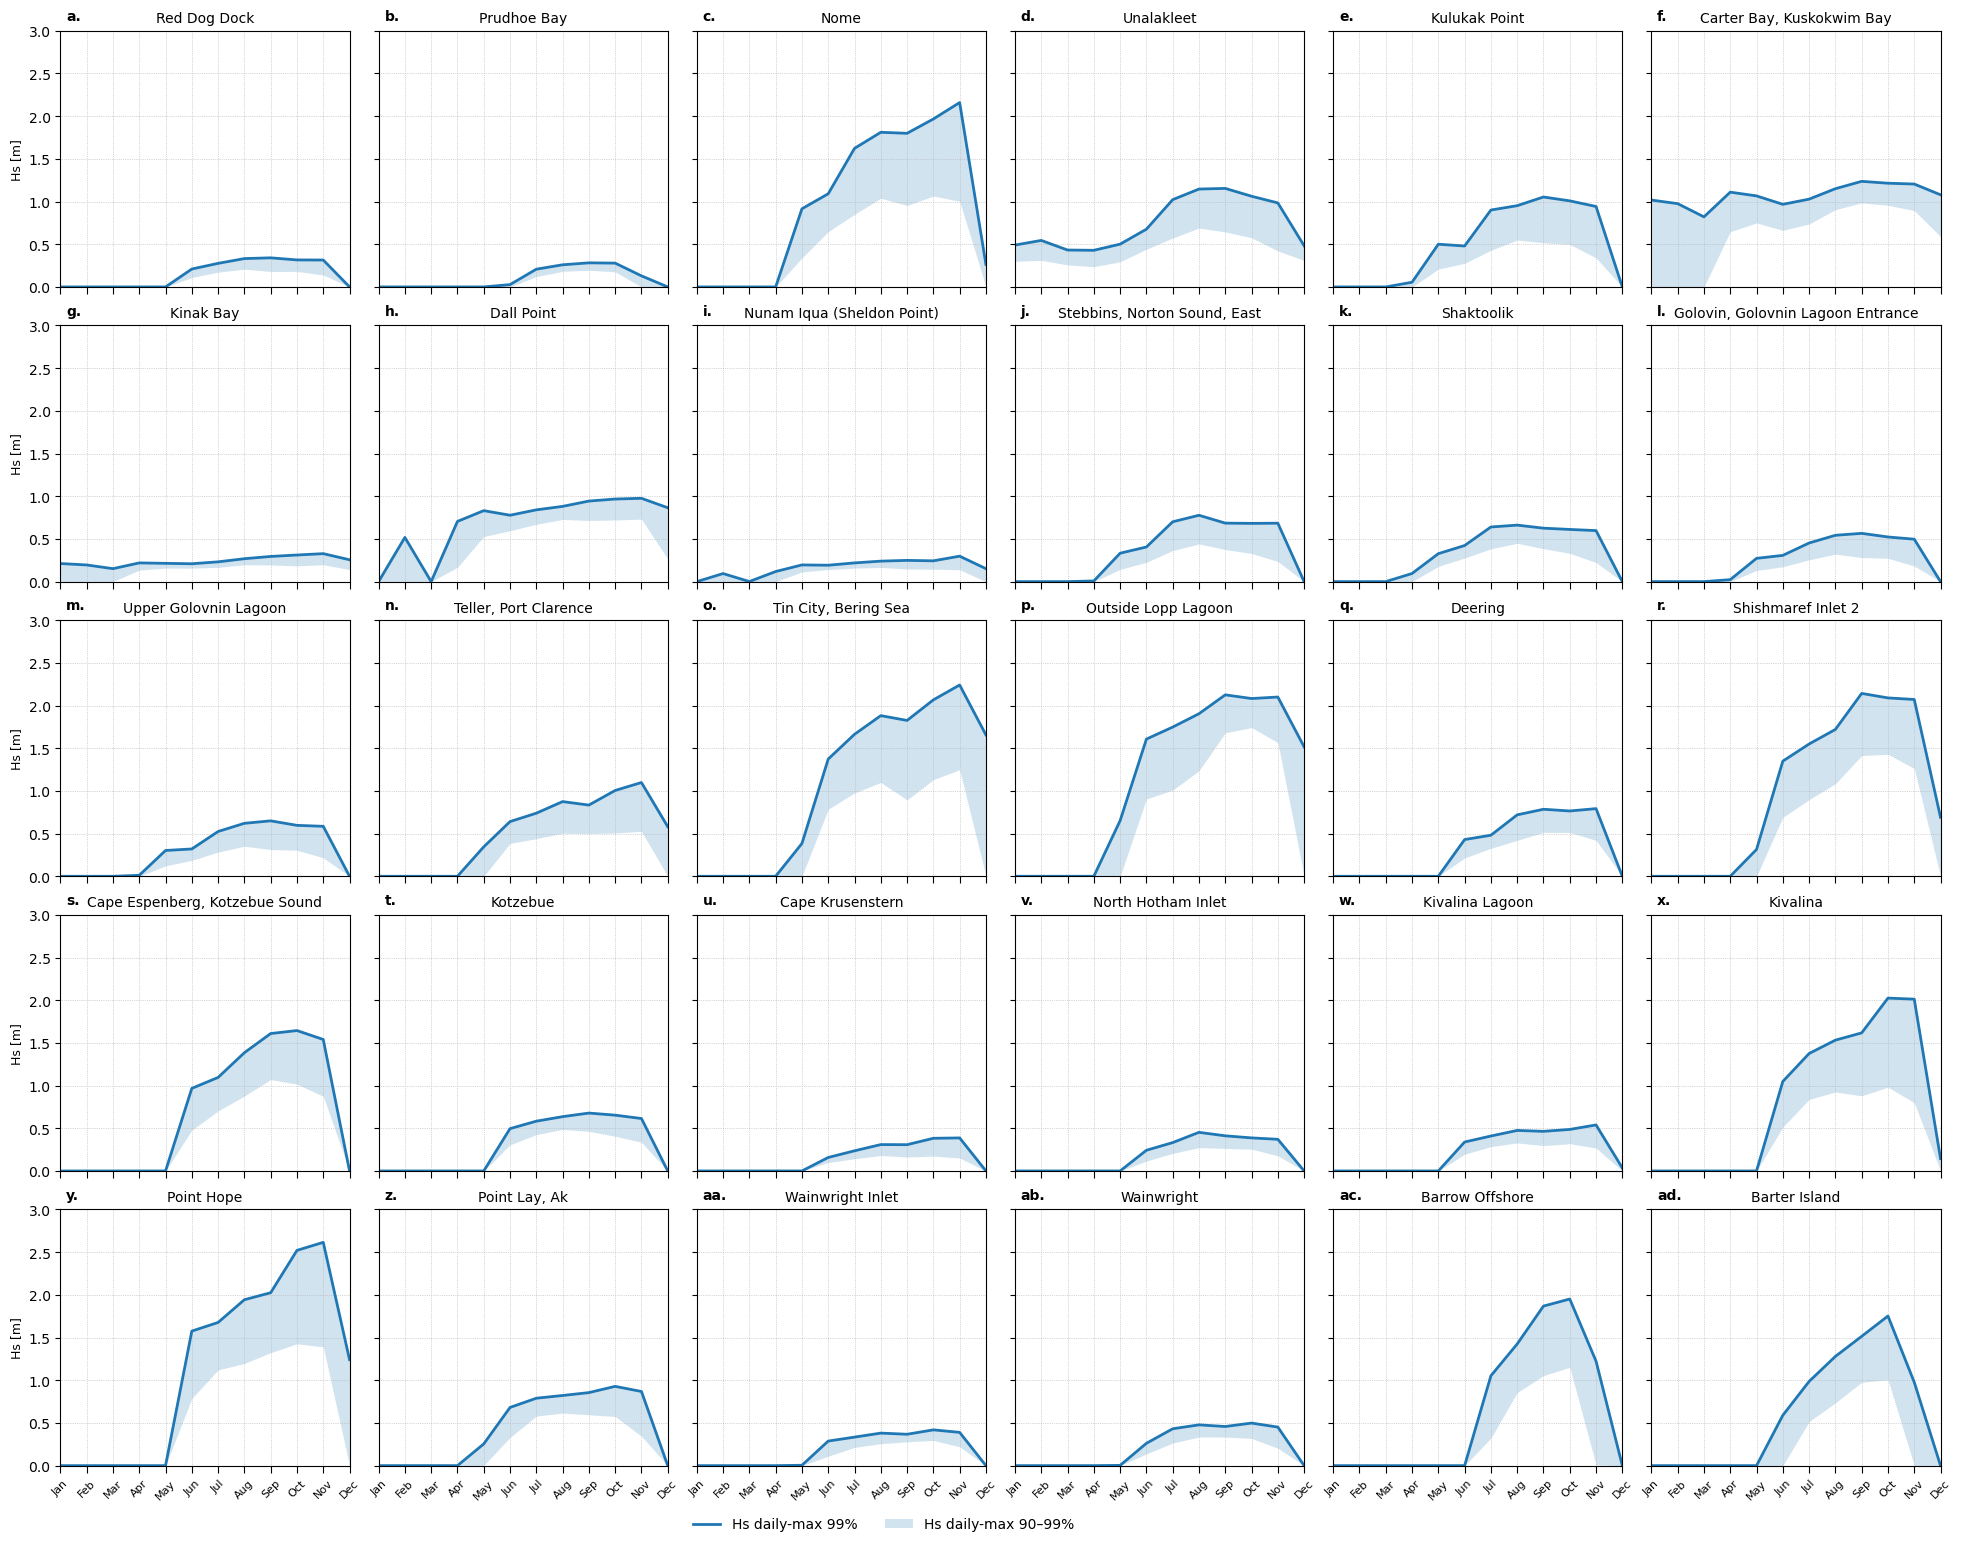

In [5]:
letters = ['a.','b.','c.','d.','e.','f.','g.','h.','i.','j.',
           'k.','l.','m.','n.','o.','p.','q.','r.','s.','t.',
           'u.','v.','w.','x.','y.','z.','aa.','ab.','ac.','ad.',
           'ae.','af.','ag.','ah.','ai.','aj.','ak.','al.','am.','an.']

months = np.arange(1, 13)
band_color = "tab:blue"
line_color = "tab:blue"
vmin, vmax = 0.0, 3  # adjust as needed

# choose communities to plot
comms_ordered = [
    'red dog dock','prudhoe bay','nome','unalakleet',
    'kulukak point','carter bay, kuskokwim bay','kinak bay','dall point',
    'nunam iqua (sheldon point)','stebbins, norton sound, east','shaktoolik',
    'golovin, golovnin lagoon entrance','upper golovnin lagoon',
    'teller, port clarence','tin city, bering sea','outside lopp lagoon',
    'deering','shishmaref inlet 2','cape espenberg, kotzebue sound',
    'kotzebue','cape krusenstern','north hotham inlet','kivalina lagoon',
    'kivalina','point hope','point lay, ak','wainwright inlet','wainwright',
    'barrow offshore','barter island'
]

comms_to_plot = comms_ordered #if 'comms_ordered' in globals() or 'comms_ordered' in locals() else unique_comms

n     = len(comms_to_plot)
ncols = int(math.ceil(math.sqrt(n)))
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*3.25, nrows*3.0),
    sharex=False,
    constrained_layout=True
)
axes = np.atleast_2d(axes)

for idx, comm in enumerate(comms_to_plot):
    r = idx // ncols
    c = idx % ncols
    ax = axes[r, c]

    ccl = monthly_data.get(comm, {}).get('climo_daily', {})
    p90 = np.array([ccl.get(m, {}).get('hs_p90', np.nan) for m in months], dtype=float)
    p99 = np.array([ccl.get(m, {}).get('hs_p99', np.nan) for m in months], dtype=float)

    good = np.isfinite(p90) & np.isfinite(p99)
    if good.any():
        mo = months.astype(float)
        ax.fill_between(mo[good], p90[good], p99[good],
                        color=band_color, alpha=0.20, linewidth=0, zorder=1,
                        label="Hs daily-max 90–99%")
        ax.plot(mo[good], p99[good],
                color=line_color, lw=2.0, zorder=2, label="Hs daily-max 99%")

    # Formatting
    ax.set_ylim(vmin, vmax)
    ax.set_xlim(1, 12)
    ax.set_xticks(range(1, 13))
    if r == nrows - 1:  # show month labels only on bottom row
        ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)],
                           rotation=45, fontsize=8)
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis='x', length=5)
    if c == 0:
        ax.set_ylabel("Hs [m]", fontsize=9)
    else:
        ax.set_yticklabels([])

    ax.set_title(comm.title(), fontsize=10)
    ax.grid(True, linestyle=':', linewidth=0.5)
    if idx < len(letters):
        ax.text(0.02, 1.03, letters[idx], transform=ax.transAxes,
                fontsize=10, weight='bold', va='bottom')

# Hide unused axes
for i in range(n, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis('off')

# Legend (single, compact)
handles = [
    mpl.lines.Line2D([0],[0], color=line_color, lw=2, label="Hs daily-max 99%"),
    mpl.patches.Patch(facecolor=band_color, alpha=0.20, label="Hs daily-max 90–99%"),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(.45, .0),
           ncol=2, fontsize=10, frameon=False)

plt.savefig('/scratch/tmiesse/project/figures/seasonal_wave_climo_dailymax_90_99.png',
            dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

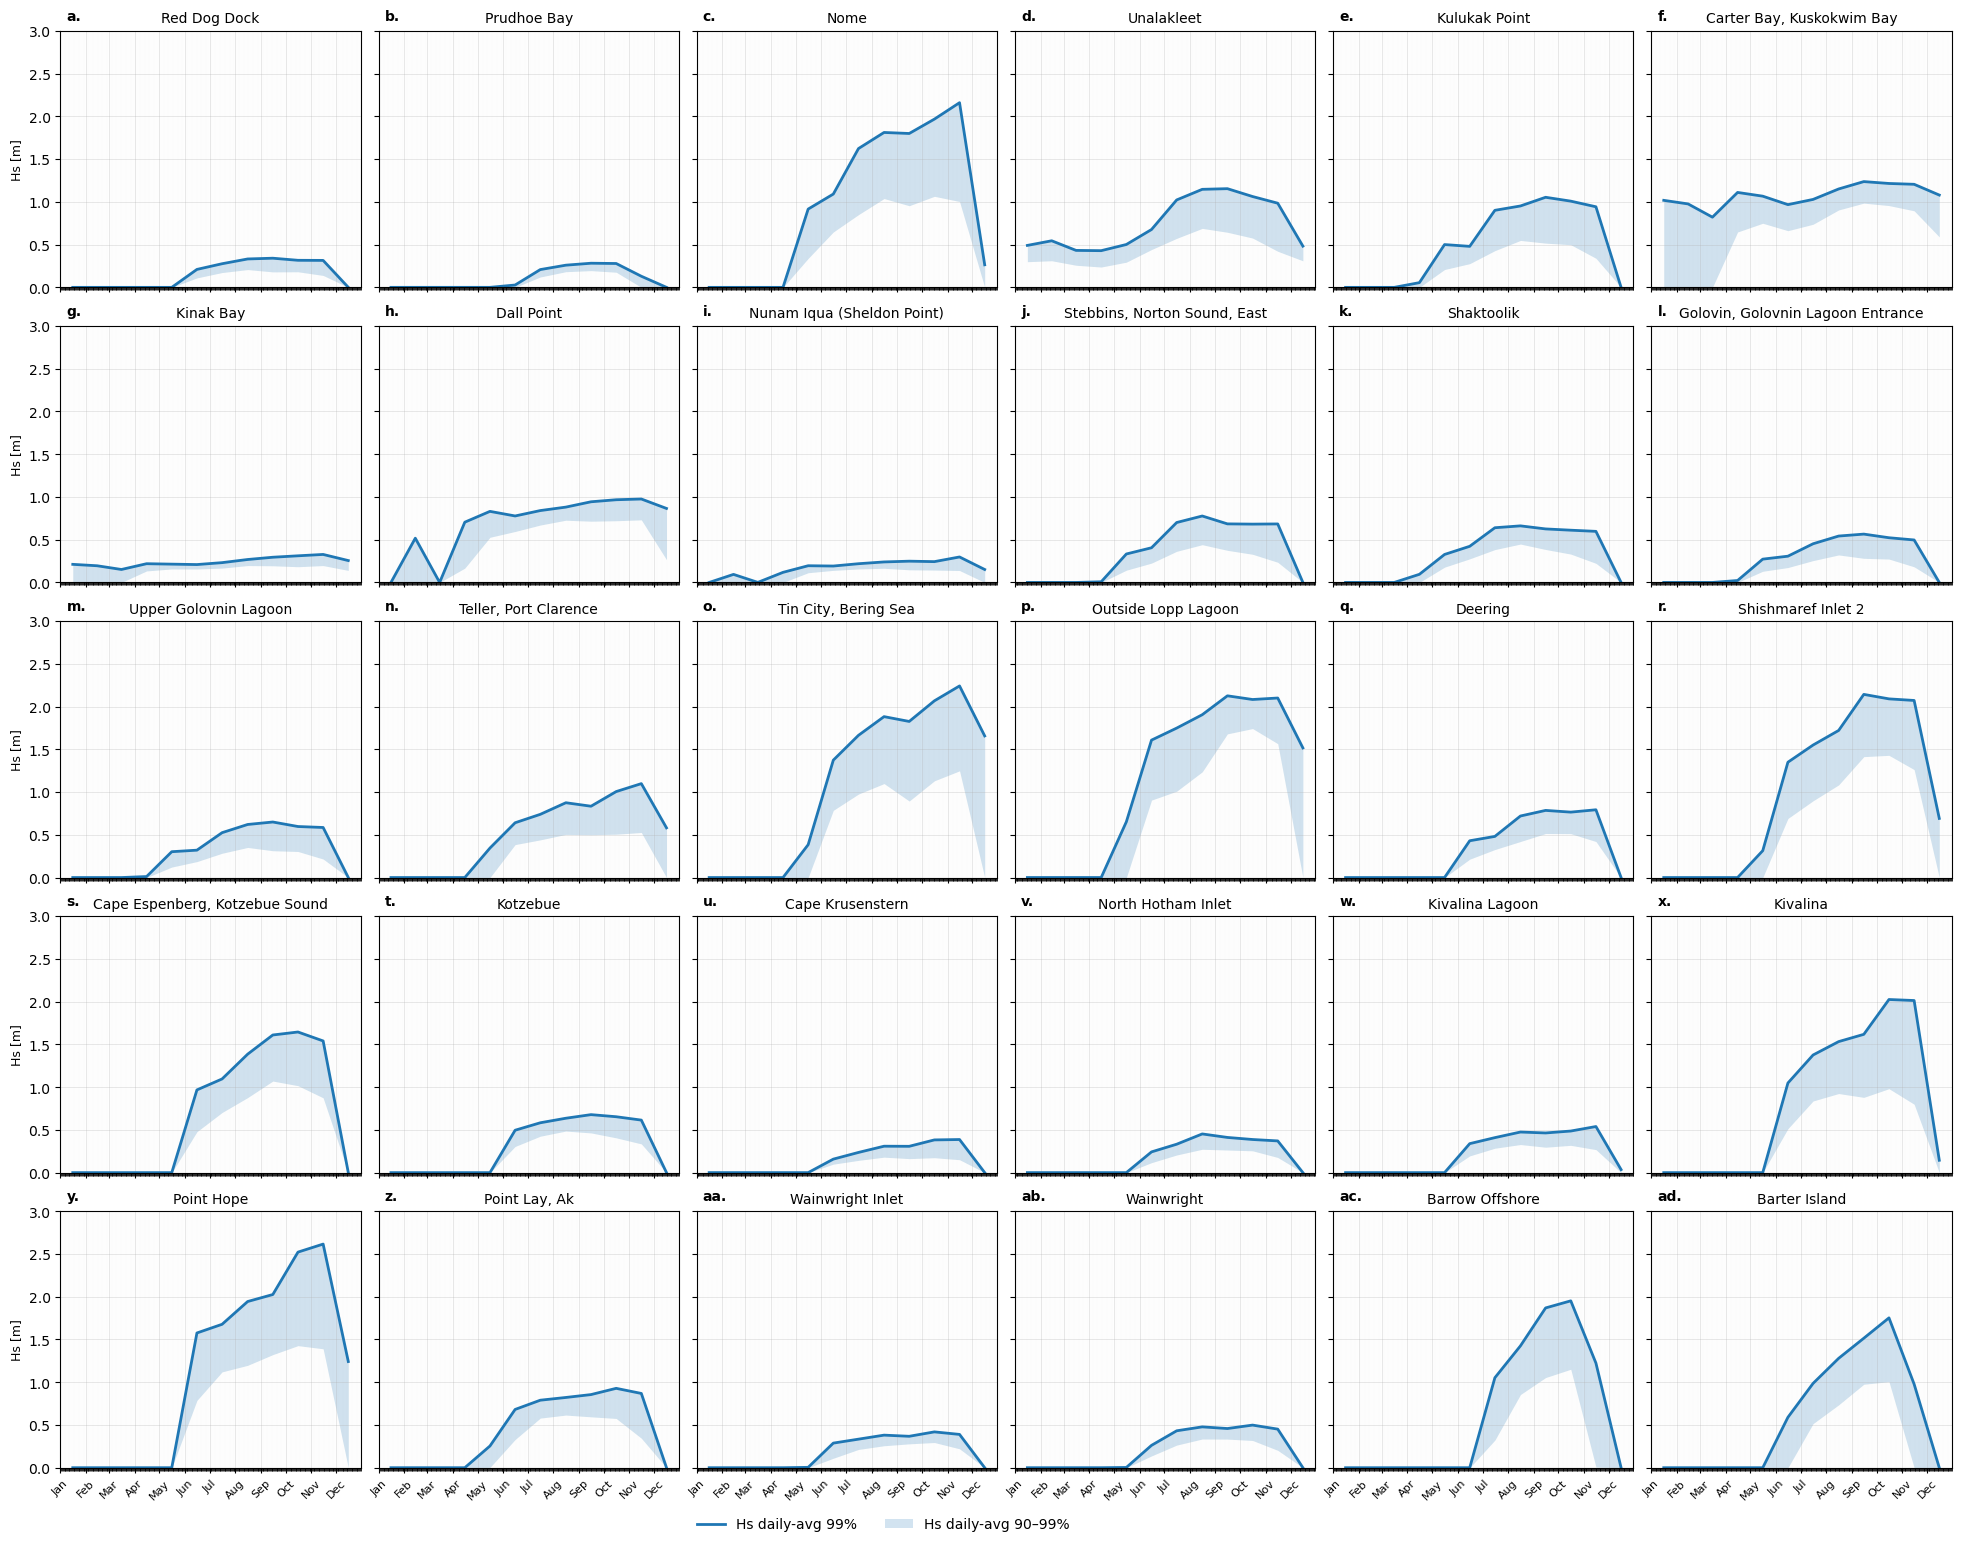

In [6]:
from matplotlib.ticker import MultipleLocator
letters = ['a.','b.','c.','d.','e.','f.','g.','h.','i.','j.',
           'k.','l.','m.','n.','o.','p.','q.','r.','s.','t.',
           'u.','v.','w.','x.','y.','z.','aa.','ab.','ac.','ad.',
           'ae.','af.','ag.','ah.','ai.','aj.','ak.','al.','am.','an.']

months = np.arange(1, 13)
band_color = "tab:blue"
line_color = "tab:blue"
vmin, vmax = 0.0, 3

# --- DOY helpers (non-leap year) ---
days_in_month = np.array([calendar.monthrange(2001, m)[1] for m in months])
doy_start = np.concatenate(([1], 1 + np.cumsum(days_in_month)[:-1]))            # first day of each month (1-based DOY)
doy_center = doy_start + (days_in_month - 1) / 2.0                              # center of each month
doy_end = 365

# choose communities to plot
comms_ordered = [
    'red dog dock','prudhoe bay','nome','unalakleet',
    'kulukak point','carter bay, kuskokwim bay','kinak bay','dall point',
    'nunam iqua (sheldon point)','stebbins, norton sound, east','shaktoolik',
    'golovin, golovnin lagoon entrance','upper golovnin lagoon',
    'teller, port clarence','tin city, bering sea','outside lopp lagoon',
    'deering','shishmaref inlet 2','cape espenberg, kotzebue sound',
    'kotzebue','cape krusenstern','north hotham inlet','kivalina lagoon',
    'kivalina','point hope','point lay, ak','wainwright inlet','wainwright',
    'barrow offshore','barter island'
]
comms_to_plot = comms_ordered

n = len(comms_to_plot)
ncols = int(math.ceil(math.sqrt(n)))
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*3.25, nrows*3.0),
    sharex=False,
    constrained_layout=True
)
axes = np.atleast_2d(axes)

for idx, comm in enumerate(comms_to_plot):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    ccl = monthly_data.get(comm, {}).get('climo_daily', {})
    p90 = np.array([ccl.get(m, {}).get('hs_p90', np.nan) for m in months], dtype=float)
    p99 = np.array([ccl.get(m, {}).get('hs_p99', np.nan) for m in months], dtype=float)

    good = np.isfinite(p90) & np.isfinite(p99)
    if good.any():
        x = doy_center.astype(float)
        ax.fill_between(x[good], p90[good], p99[good],
                        color=band_color, alpha=0.20, linewidth=0, zorder=1,
                        label="Hs daily-avg 90–99%")
        ax.plot(x[good], p99[good],
                color=line_color, lw=2.0, zorder=2, label="Hs daily-avg 99%")

    # Axes formatting on DOY
    ax.set_ylim(vmin, vmax)
    ax.set_xlim(1, doy_end)
    ax.set_xticks(doy_start)  # major ticks: month boundaries
    month_labels = [calendar.month_abbr[m] for m in months]
    if r == nrows - 1:
        ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    else:
        ax.set_xticklabels([])

    # Minor ticks: daily (or use 5 for sparser grid)
    ax.xaxis.set_minor_locator(MultipleLocator(1))    # every day
    ax.tick_params(axis='x', which='minor', length=2) # short minor ticks, no labels

    # Light grid for days and months
    ax.grid(True, which='major', linestyle='-', linewidth=0.4, alpha=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.1, alpha=0.3)

    if c == 0:
        ax.set_ylabel("Hs [m]", fontsize=9)
    else:
        ax.set_yticklabels([])

    ax.set_title(comm.title(), fontsize=10)
    if idx < len(letters):
        ax.text(0.02, 1.03, letters[idx], transform=ax.transAxes,
                fontsize=10, weight='bold', va='bottom')

# Hide unused axes
for i in range(n, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

# Legend (single, compact)
handles = [
    mpl.lines.Line2D([0],[0], color=line_color, lw=2, label="Hs daily-avg 99%"),
    mpl.patches.Patch(facecolor=band_color, alpha=0.20, label="Hs daily-avg 90–99%"),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(.45, .0),
           ncol=2, fontsize=10, frameon=False)

plt.savefig('/scratch/tmiesse/project/figures/seasonal_wave_climo_dailyavg_90_99_DOY.png',
            dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

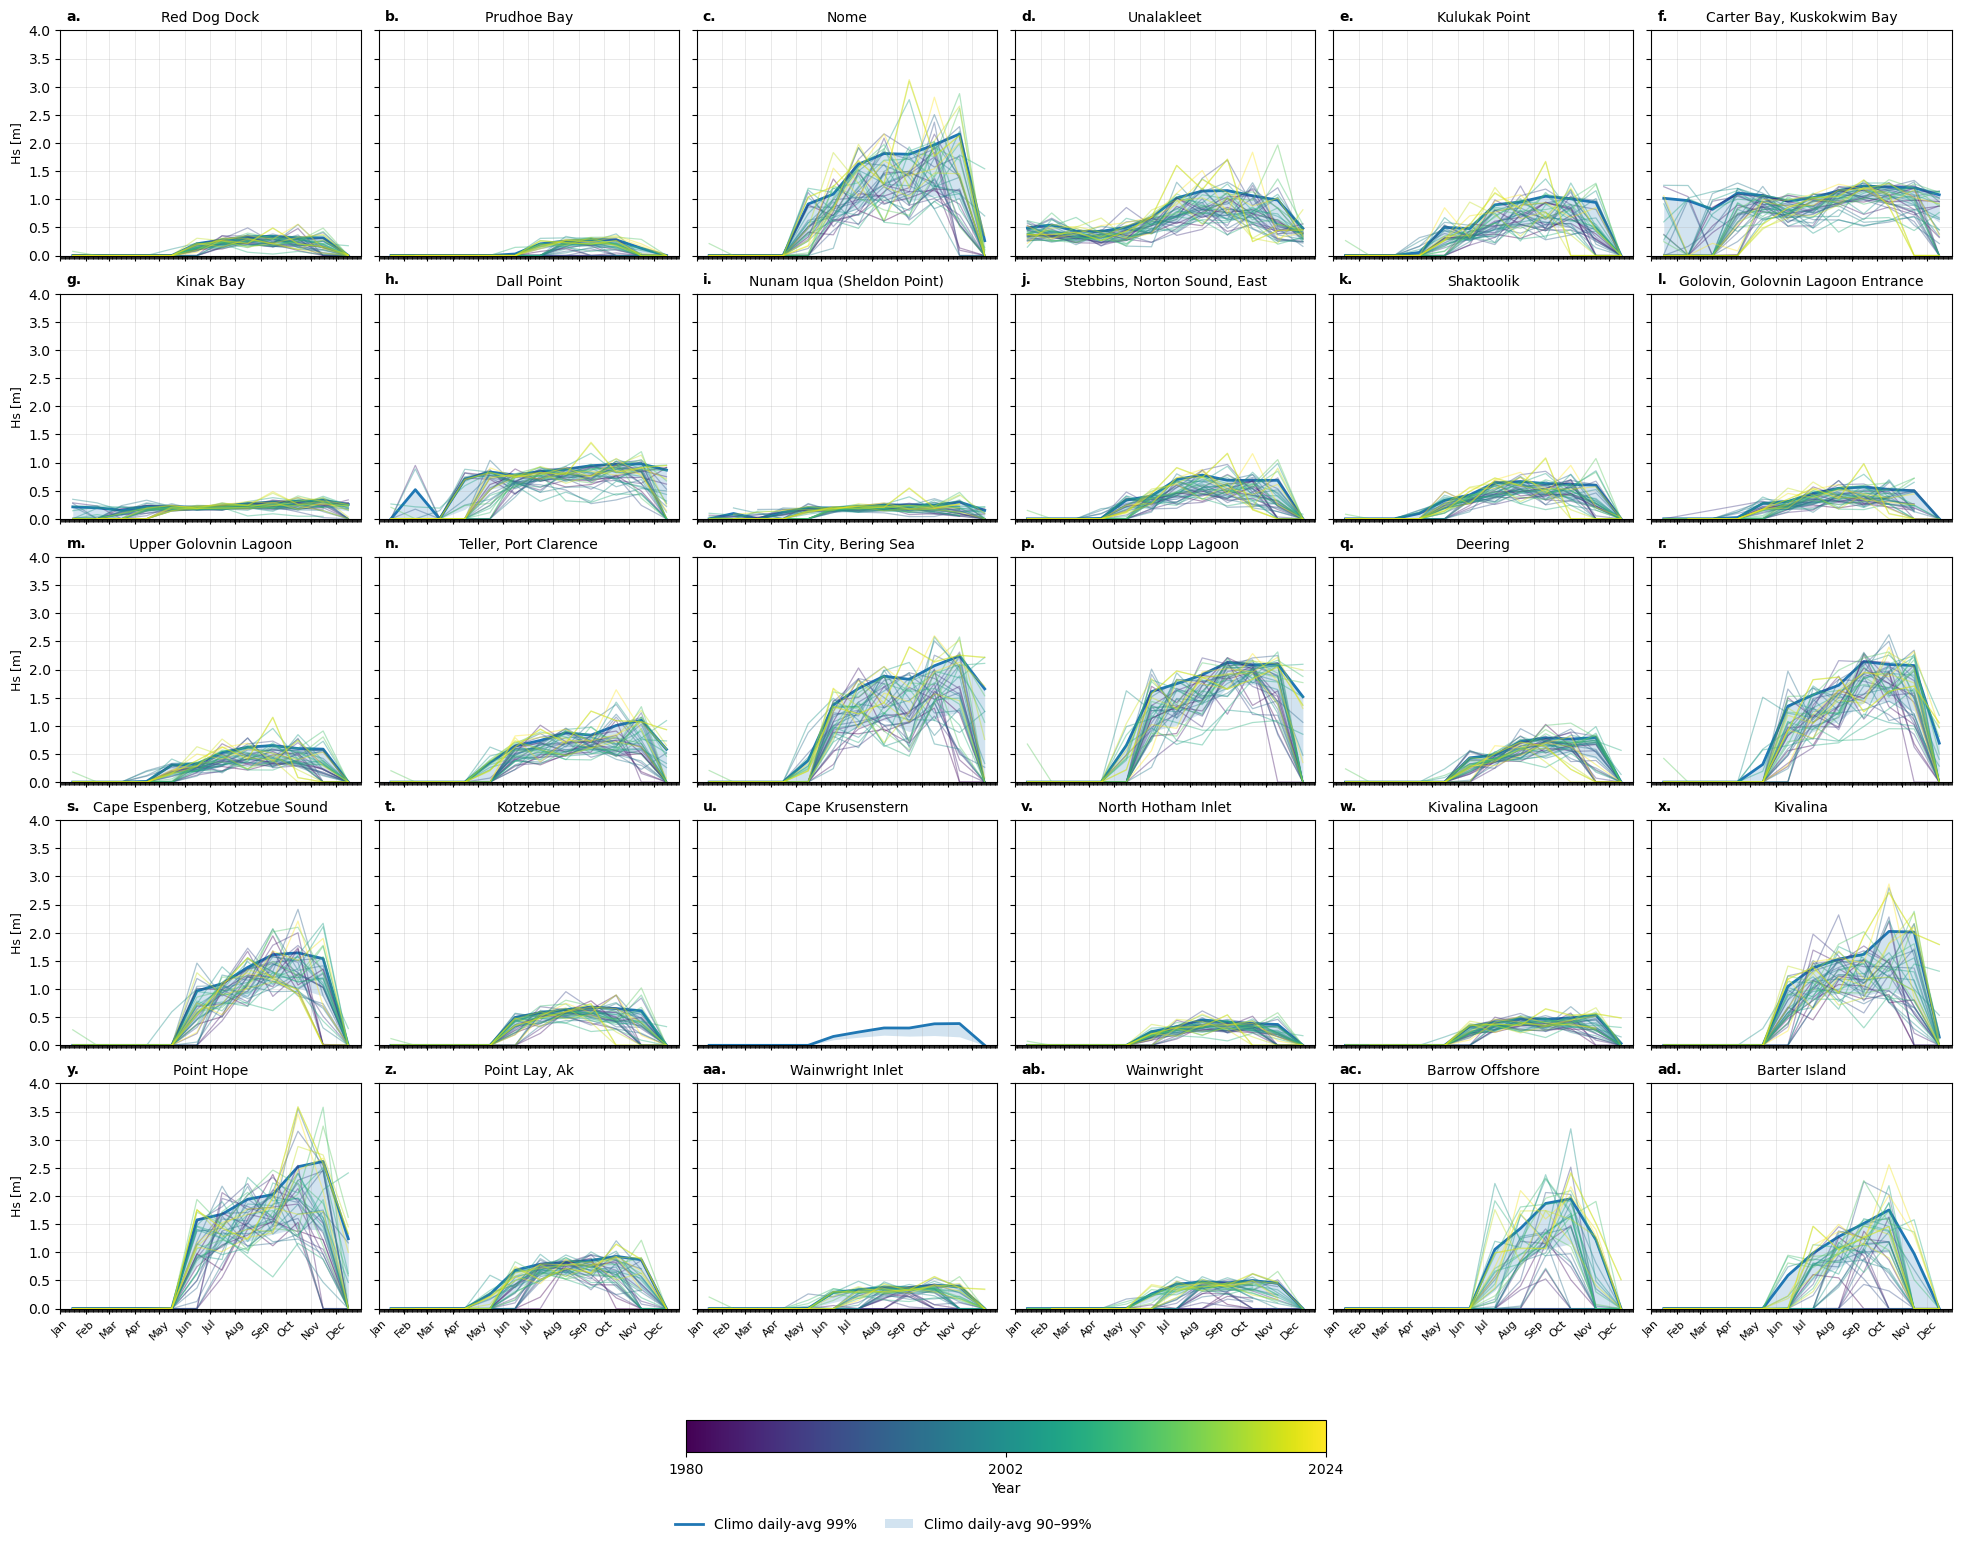

In [7]:

letters = ['a.','b.','c.','d.','e.','f.','g.','h.','i.','j.',
           'k.','l.','m.','n.','o.','p.','q.','r.','s.','t.',
           'u.','v.','w.','x.','y.','z.','aa.','ab.','ac.','ad.',
           'ae.','af.','ag.','ah.','ai.','aj.','ak.','al.','am.','an.']

months = np.arange(1, 13)
band_color = "tab:blue"
line_color = "tab:blue"
vmin, vmax = 0.0, 4.0

# --- DOY helpers (non-leap year) ---
days_in_month = np.array([calendar.monthrange(2001, m)[1] for m in months])
doy_start  = np.concatenate(([1], 1 + np.cumsum(days_in_month)[:-1]))
doy_center = doy_start + (days_in_month - 1) / 2.0
doy_end    = 365

# choose communities to plot
comms_ordered = [
    'red dog dock','prudhoe bay','nome','unalakleet',
    'kulukak point','carter bay, kuskokwim bay','kinak bay','dall point',
    'nunam iqua (sheldon point)','stebbins, norton sound, east','shaktoolik',
    'golovin, golovnin lagoon entrance','upper golovnin lagoon',
    'teller, port clarence','tin city, bering sea','outside lopp lagoon',
    'deering','shishmaref inlet 2','cape espenberg, kotzebue sound',
    'kotzebue','cape krusenstern','north hotham inlet','kivalina lagoon',
    'kivalina','point hope','point lay, ak','wainwright inlet','wainwright',
    'barrow offshore','barter island'
]
comms_to_plot = comms_ordered

# --- year colormap for overlay lines ---
yr_min, yr_max = 1980, 2024
yrs = np.arange(yr_min, yr_max + 1)
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=yr_min, vmax=yr_max)
sm   = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)  # for colorbar

n = len(comms_to_plot)
ncols = int(math.ceil(math.sqrt(n)))
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*3.25, nrows*3.0),
    sharex=False,
    constrained_layout=True
)
axes = np.atleast_2d(axes)

for idx, comm in enumerate(comms_to_plot):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    # Band from daily-avg climatology percentiles
    ccl = monthly_data.get(comm, {}).get('climo_daily', {})
    p90 = np.array([ccl.get(m, {}).get('hs_p90', np.nan) for m in months], float)
    p99 = np.array([ccl.get(m, {}).get('hs_p99', np.nan) for m in months], float)
    good = np.isfinite(p90) & np.isfinite(p99)
    if good.any():
        x = doy_center.astype(float)
        ax.fill_between(x[good], p90[good], p99[good],
                        color=band_color, alpha=0.20, linewidth=0, zorder=1,
                        label="Hs daily-avg 90–99%")
        ax.plot(x[good], p99[good],
                color=line_color, lw=2.0, zorder=2, label="Hs daily-avg 99% (climo)")

    # --- Per-year overlays: daily-avg 99th percentile per month (12 pts) ---
    # requires: raw[comm]['time'], raw[comm]['hs'], and iterable `years`
    t_vals = to_datetime64ns(np.array(raw[comm]['time']))
    hs_vals = np.asarray(raw[comm]['hs'], dtype=float)
    msk = np.isfinite(hs_vals)
    df = pd.DataFrame({'hs': hs_vals[msk]}, index=pd.to_datetime(t_vals[msk])).sort_index()
    daily = df['hs'].resample('1D').mean()  # daily averages

    for yr in yrs:
        seg = daily[daily.index.year == yr]
        if seg.empty:
            continue
        y99 = np.full(12, np.nan, dtype=float)
        for i, m in enumerate(months, start=0):
            vals = seg[seg.index.month == m].values
            if vals.size:
                y99[i] = np.percentile(vals, 99)
        g2 = np.isfinite(y99)
        if g2.any():
            ax.plot(doy_center[g2], y99[g2],
                    lw=0.9, alpha=0.4, color=cmap(norm(yr)), zorder=3)

    # Axes formatting on DOY with daily minor ticks (unlabeled)
    ax.set_ylim(vmin, vmax)
    ax.set_xlim(1, doy_end)
    ax.set_xticks(doy_start)
    month_labels = [calendar.month_abbr[m] for m in months]
    if r == nrows - 1:
        ax.set_xticklabels(month_labels, rotation=45, fontsize=8)
    else:
        ax.set_xticklabels([])
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.tick_params(axis='x', which='minor', length=2)

    ax.grid(True, which='major', linestyle='-',  linewidth=0.4, alpha=0.5)
    ax.grid(True, which='minor', linestyle=':',  linewidth=0.01, alpha=0.25)

    if c == 0:
        ax.set_ylabel("Hs [m]", fontsize=9)
    else:
        ax.set_yticklabels([])

    ax.set_title(comm.title(), fontsize=10)
    if idx < len(letters):
        ax.text(0.02, 1.03, letters[idx], transform=ax.transAxes,
                fontsize=10, weight='bold', va='bottom')

# Hide unused axes
for i in range(n, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

# Legend for band + climo line; colorbar for years
handles = [
    mpl.lines.Line2D([0],[0], color=line_color, lw=2, label="Climo daily-avg 99%"),
    mpl.patches.Patch(facecolor=band_color, alpha=0.20, label="Climo daily-avg 90–99%"),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(.45, .0),
           ncol=2, fontsize=10, frameon=False)

cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                    fraction=0.025, pad=0.06)
cbar.set_label("Year")
cbar.set_ticks([yr_min, (yr_min+yr_max)//2, yr_max])
cbar.set_ticklabels([str(yr_min), str((yr_min+yr_max)//2), str(yr_max)])

plt.savefig('/scratch/tmiesse/project/figures/seasonal_wave_climo_dailyavg_90_99_DOY_yearlines.png',
            dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

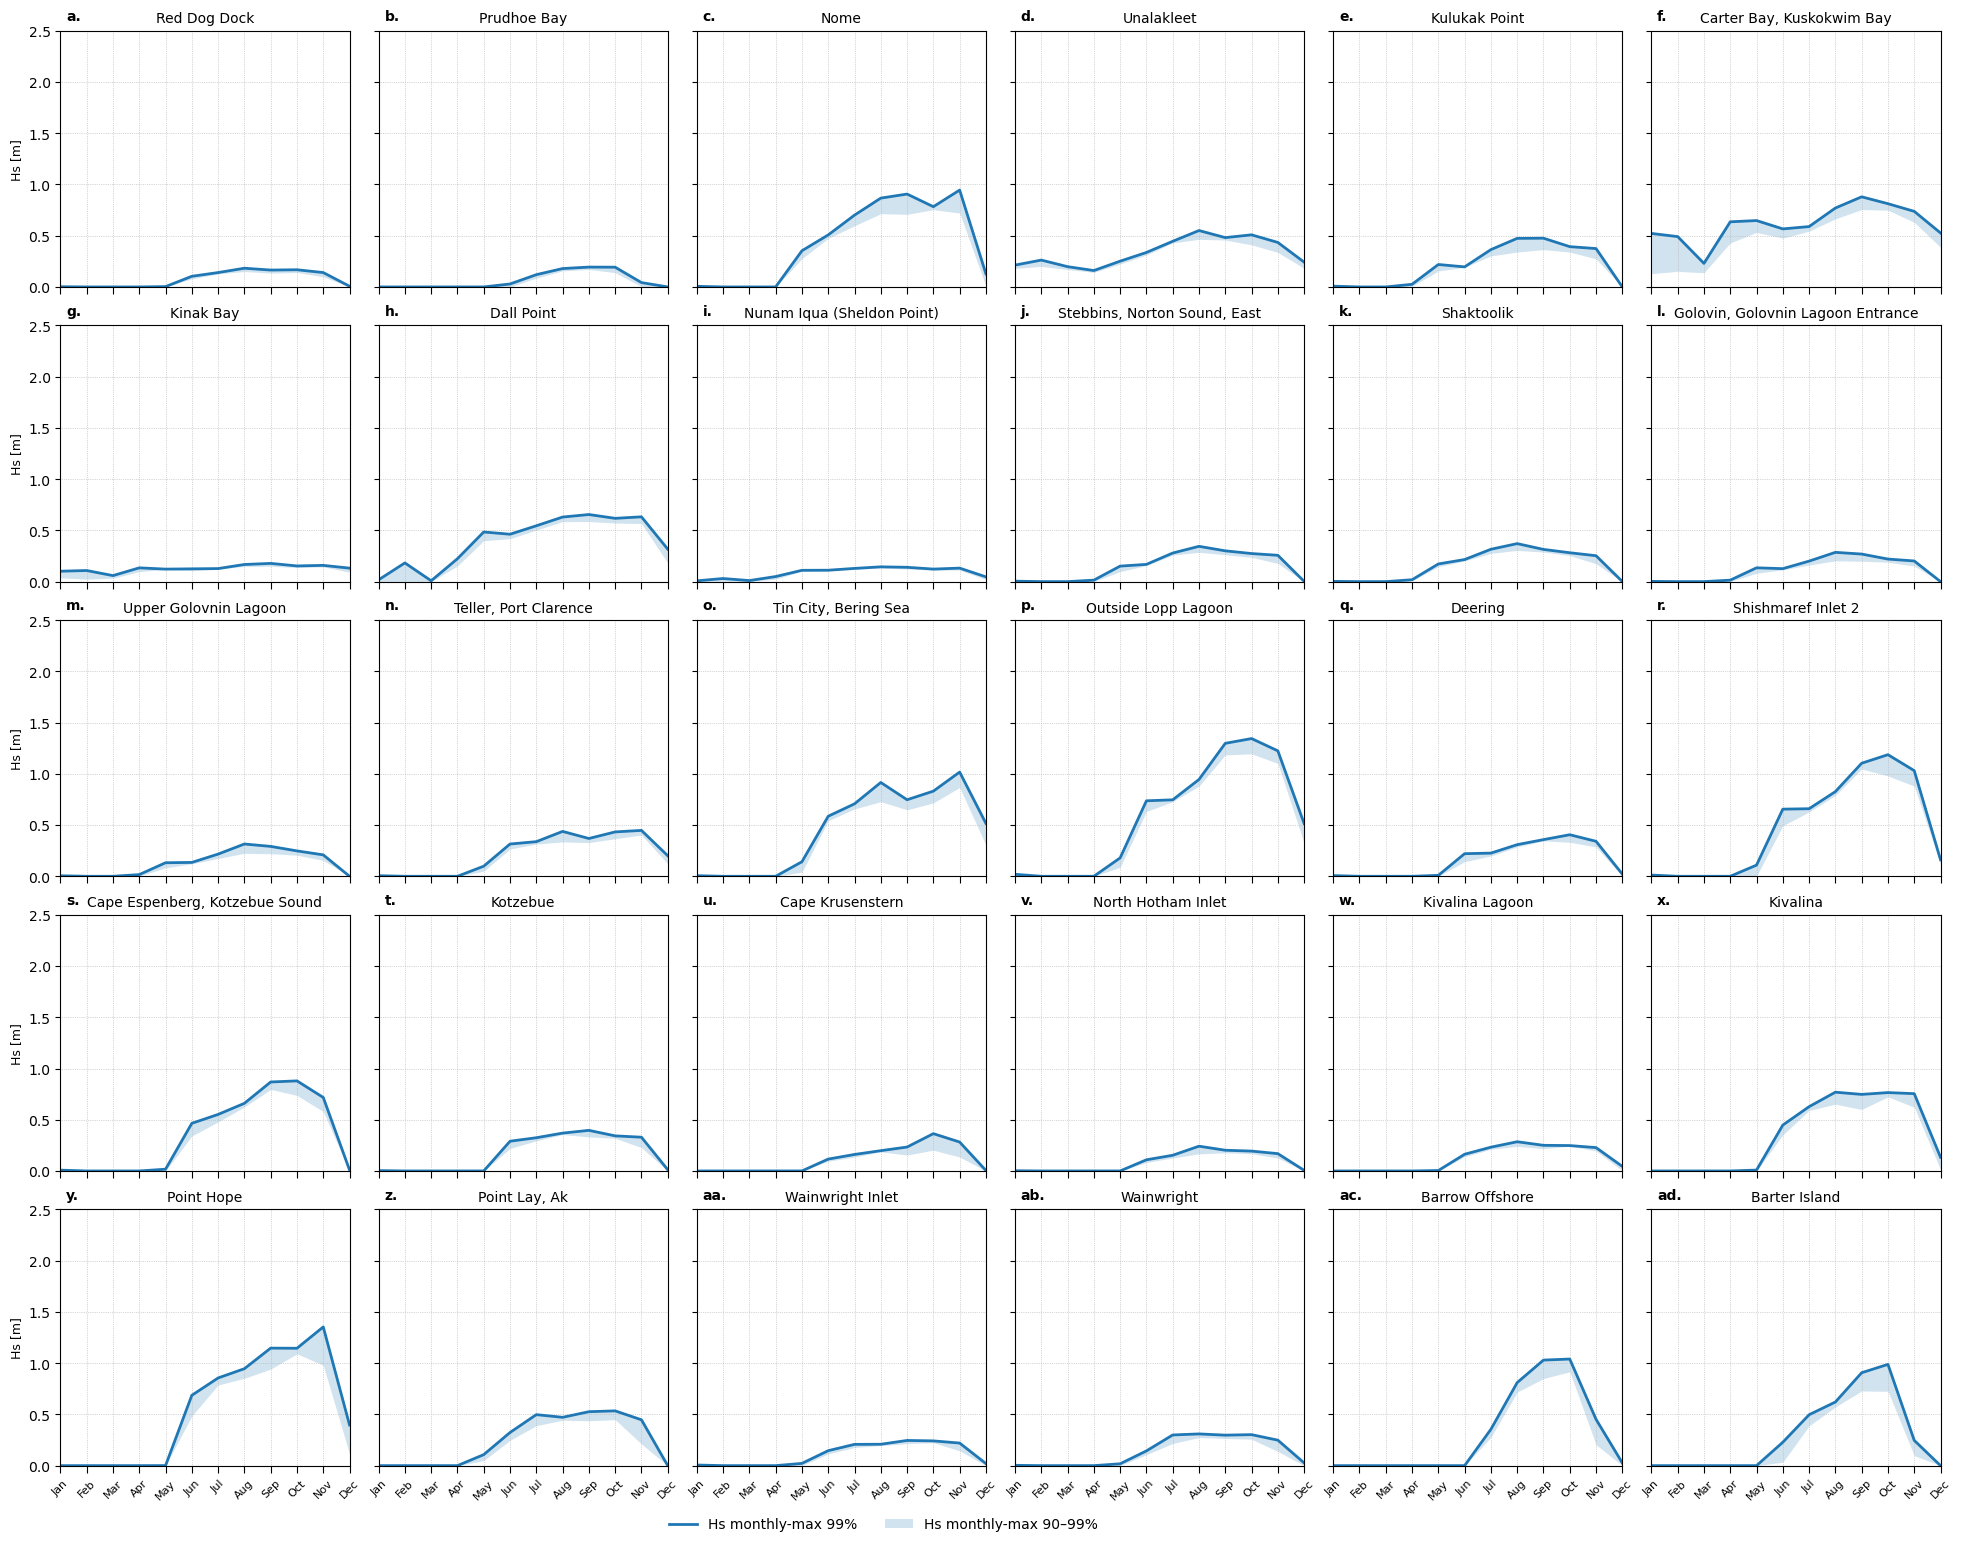

In [ ]:
letters = ['a.','b.','c.','d.','e.','f.','g.','h.','i.','j.',
           'k.','l.','m.','n.','o.','p.','q.','r.','s.','t.',
           'u.','v.','w.','x.','y.','z.','aa.','ab.','ac.','ad.',
           'ae.','af.','ag.','ah.','ai.','aj.','ak.','al.','am.','an.']

months = np.arange(1, 13)
band_color = "tab:blue"
line_color = "tab:blue"
vmin, vmax = 0.0, 2.5

comms_ordered = [
    'red dog dock','prudhoe bay','nome','unalakleet',
    'kulukak point','carter bay, kuskokwim bay','kinak bay','dall point',
    'nunam iqua (sheldon point)','stebbins, norton sound, east','shaktoolik',
    'golovin, golovnin lagoon entrance','upper golovnin lagoon',
    'teller, port clarence','tin city, bering sea','outside lopp lagoon',
    'deering','shishmaref inlet 2','cape espenberg, kotzebue sound',
    'kotzebue','cape krusenstern','north hotham inlet','kivalina lagoon',
    'kivalina','point hope','point lay, ak','wainwright inlet','wainwright',
    'barrow offshore','barter island'
]

comms_to_plot = comms_ordered

# --- plotting layout ---
n = len(comms_to_plot)
ncols = int(math.ceil(math.sqrt(n)))
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols*3.25, nrows*3.0),
    sharex=False,
    constrained_layout=True
)
axes = np.atleast_2d(axes)

for idx, comm in enumerate(comms_to_plot):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    # CHANGED: use monthly climatology instead of daily
    ccl = monthly_data.get(comm, {}).get('climo_monthly', {})

    p90 = np.array([ccl.get(m, {}).get('hs_p90', np.nan) for m in months], float)
    p99 = np.array([ccl.get(m, {}).get('hs_p99', np.nan) for m in months], float)

    good = np.isfinite(p90) & np.isfinite(p99)
    if good.any():
        mo = months.astype(float)
        ax.fill_between(mo[good], p90[good], p99[good],
                        color=band_color, alpha=0.20, linewidth=0, zorder=1,
                        label="Hs monthly-max 90–99%")
        ax.plot(mo[good], p99[good],
                color=line_color, lw=2.0, zorder=2, label="Hs monthly-max 99%")

    ax.set_ylim(vmin, vmax)
    ax.set_xlim(1, 12)
    ax.set_xticks(range(1, 13))
    if r == nrows - 1:
        ax.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)],
                           rotation=45, fontsize=8)
    else:
        ax.set_xticklabels([])
    ax.tick_params(axis='x', length=5)

    if c == 0:
        ax.set_ylabel("Hs [m]", fontsize=9)
    else:
        ax.set_yticklabels([])

    ax.set_title(comm.title(), fontsize=10)
    ax.grid(True, linestyle=':', linewidth=0.5)
    if idx < len(letters):
        ax.text(0.02, 1.03, letters[idx], transform=ax.transAxes,
                fontsize=10, weight='bold', va='bottom')

# hide unused axes
for i in range(n, nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

# legend
handles = [
    mpl.lines.Line2D([0],[0], color=line_color, lw=2, label="Hs monthly-max 99%"),
    mpl.patches.Patch(facecolor=band_color, alpha=0.20, label="Hs monthly-max 90–99%"),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(.45, .0),
           ncol=2, fontsize=10, frameon=False)

plt.savefig('/scratch/tmiesse/project/figures/seasonal_wave_climo_monthlymax_90_99.png',
            dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()